# Explore your data !

Authors:
* Thomas Lecocq, Royal Observatory of Belgium
* Koen Van Noten,  Royal Observatory of Belgium

## Setup and Imports

Basic setup for seismic time series analysis:
- matplotlib: For plotting (inline mode)
- numpy: For numerical operations
- obspy: For seismic data handling
  - UTCDateTime: Time handling
  - read: Data reading
  - Stream: Seismic data container
- obspy.signal.filter: For envelope calculation
- pandas: For time series handling
- glob: For file path pattern matching

In [1]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
import numpy as np
from obspy import UTCDateTime, read, Stream
import pandas as pd
import glob
import datetime
from obspy.signal.filter import envelope
import matplotlib.cm as cm

# Data File Selection

Locates and counts seismic data files:
1. File pattern: 'DATA/SDS/2024/XG/station/EHZ.D/*'
   - Network: XG
   - Station: HB04
   - Channel: EHZ (Vertical high-frequency channel)
   - Data structure: SDS (SeisComP Data Structure)
2. Files are sorted chronologically
3. Count available files using len()

# Load and Preprocess Seismic Data

Loads and processes seismic data files:
- Iterates through files (skipping first file)
- For each file:
  1. Reads data using ObsPy
  2. Decimates by factor of 5 (reduces sampling rate)
  3. Adds to traces list
- Finally merges all traces into single Stream object

Parameters:
- decimati10 (we have enough with 20 Hz data for now)n factor: 5
- filter: Applied during decimation (no_filter=False)

Trimming options:
- adapt the start- and enddate of the stream
- when plotting many stations, you may want to use the same start- and endtime
- fill the empty trace with Nans (masked trace)

In [2]:
# Path to where you have copied the DATA/ folder (that contains the SDS, RESP etc folders)
DATA_PATH = '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/'
OUT_PATH = os.path.join(DATA_PATH, 'OUTPUT') 
if not os.path.exists(OUT_PATH):
    os.makedirs(OUT_PATH)
print(OUT_PATH)


/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/OUTPUT


In [3]:
SDS = 'SDS'
network = 'XG'
year = '2024'
## select a station from ADR1, BB01, C16, C17, C29, C2A, C65, C66, C67, C68, C69, C6A, S35, UP1, UP2, UP3, UP4, UP5, UP6
station = 'BB01'

In [4]:
files = sorted(glob.glob(os.path.join(DATA_PATH, SDS, year, network, station, 'HHZ.D', '*')))
print("%s files are loaded"%len(files))
files


4 files are loaded


['/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.079',
 '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.080',
 '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.081',
 '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.082']

# Load and Preprocess Seismic Data

Loads and processes seismic data files:
- Iterates through files (skipping first file)
- For each file:
  1. Reads data using ObsPy
  2. Decimates by factor of 5 (reduces sampling rate)
  3. Adds to traces list
- Finally merges all traces into single Stream object

Parameters:
- decimati10 (we have enough with 20 Hz data for now)n factor: 5
- filter: Applied during decimation (no_filter=False)

Trimming options:
- adapt the start- and enddate of the stream
- when plotting many stations, you may want to use the same start- and endtime
- fill the empty trace with Nans (masked trace)

In [5]:
# select if you want to trim your data, e.g. trim noisy installation hours 
trim = True
trim_starttime = "2024-03-19 15:00:00"
trim_endtime = "2024-03-23 00:00:00"

# select to use common start- and endtime for all stations
common_time = True
common_starttime = "2024-03-19 00:00:00"
common_endtime = "2024-03-23 00:00:00"

###########################
traces = []

for file in files:
    print(file)
    try:
        st = read(file)
    except:
        print(f"Error reading {file}")
        continue
    st.decimate(10, no_filter=False)
    
    # play with the filters, you might want to filter the broadband data
    st.filter('highpass', freq=0.5, corners=4, zerophase=True)
    #st.filter('bandpass', freqmin=4, freqmax=14, corners=4, zerophase=True)
    
    traces.append(st[0])
    
    del(st)
st = Stream(traces=traces)
st.merge()

if trim:
    st.trim(starttime=UTCDateTime(trim_starttime), endtime=UTCDateTime(trim_endtime))

if common_time:
    st.trim(starttime=UTCDateTime(common_starttime), endtime=UTCDateTime(common_endtime), pad=True, fill_value=None)

/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.079
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.080
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.081
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/BB01/HHZ.D/XG.BB01..HHZ.D.2024.082


# Generate Daily Seismic Plot

Creates a publication-quality day plot of seismic data:
Parameters:
- interval: 60 minutes
- format: PDF output
- style settings:
  - Color: black
  - Line width: 0.5
  - DPI: 100
  - Size: 5000x10000
  - Time format: "YYYY-MM-DD HHh"
- Layout adjustments for margins
- Output file: "1hlines.pdf"

In [6]:
outfile = "%s/%s_1hlines.pdf"%(OUT_PATH, st[0].id)
st.plot(type='dayplot', interval=60, right_vertical_labels=False,
        one_tick_per_line=True,
        color=['black'], linewidth=0.5, show_y_UTC_label=False, 
         dpi=100, size=(5000,10000), y_labels_size=10, tick_format="%Y-%m-%d %Hh",
        subplots_adjust_left=0.03, subplots_adjust_right=0.98, subplots_adjust_top=0.98, 
        subplots_adjust_bottom=0.02, outfile=outfile)


# Prepare Data for Overview Visualization

Two-step data preparation:
1. Copy and merge stream:
   - Interpolates gaps
   - Further decimates by factor of 10
2. Data transformation:
   - Convert to absolute values
   - Clip values between 0 and 1e5
   - Reduces noise and extreme values

In [7]:
st2 = st.copy()
st2 = st2.merge(method=1, fill_value="interpolate")
st2.decimate(10, no_filter=True)

st2[0].data = np.abs(st2[0].data)
st2[0].data = np.clip(st2[0].data, 0, 1e5)

st2

1 Trace(s) in Stream:
XG.BB01..HHZ | 2024-03-19T00:00:00.000000Z - 2024-03-23T00:00:00.000000Z | 2.0 Hz, 691201 samples

# Create Overview Plot with Weekend Highlighting

Generates comprehensive time series visualization:
Parameters:
- Figure size: 30x20 inches
- Plot features:
  - Black line for seismic data (width 0.5)
  - Green shaded weekends (Saturday-Monday)
  - Daily tick marks with dates
  - Automatic date formatting
- Output: "groundmotion_continuous_with_weekends.pdf"

This plot provides a complete overview of amplitudemic activity with weekend periods highlighted for context.

16.748415348062892


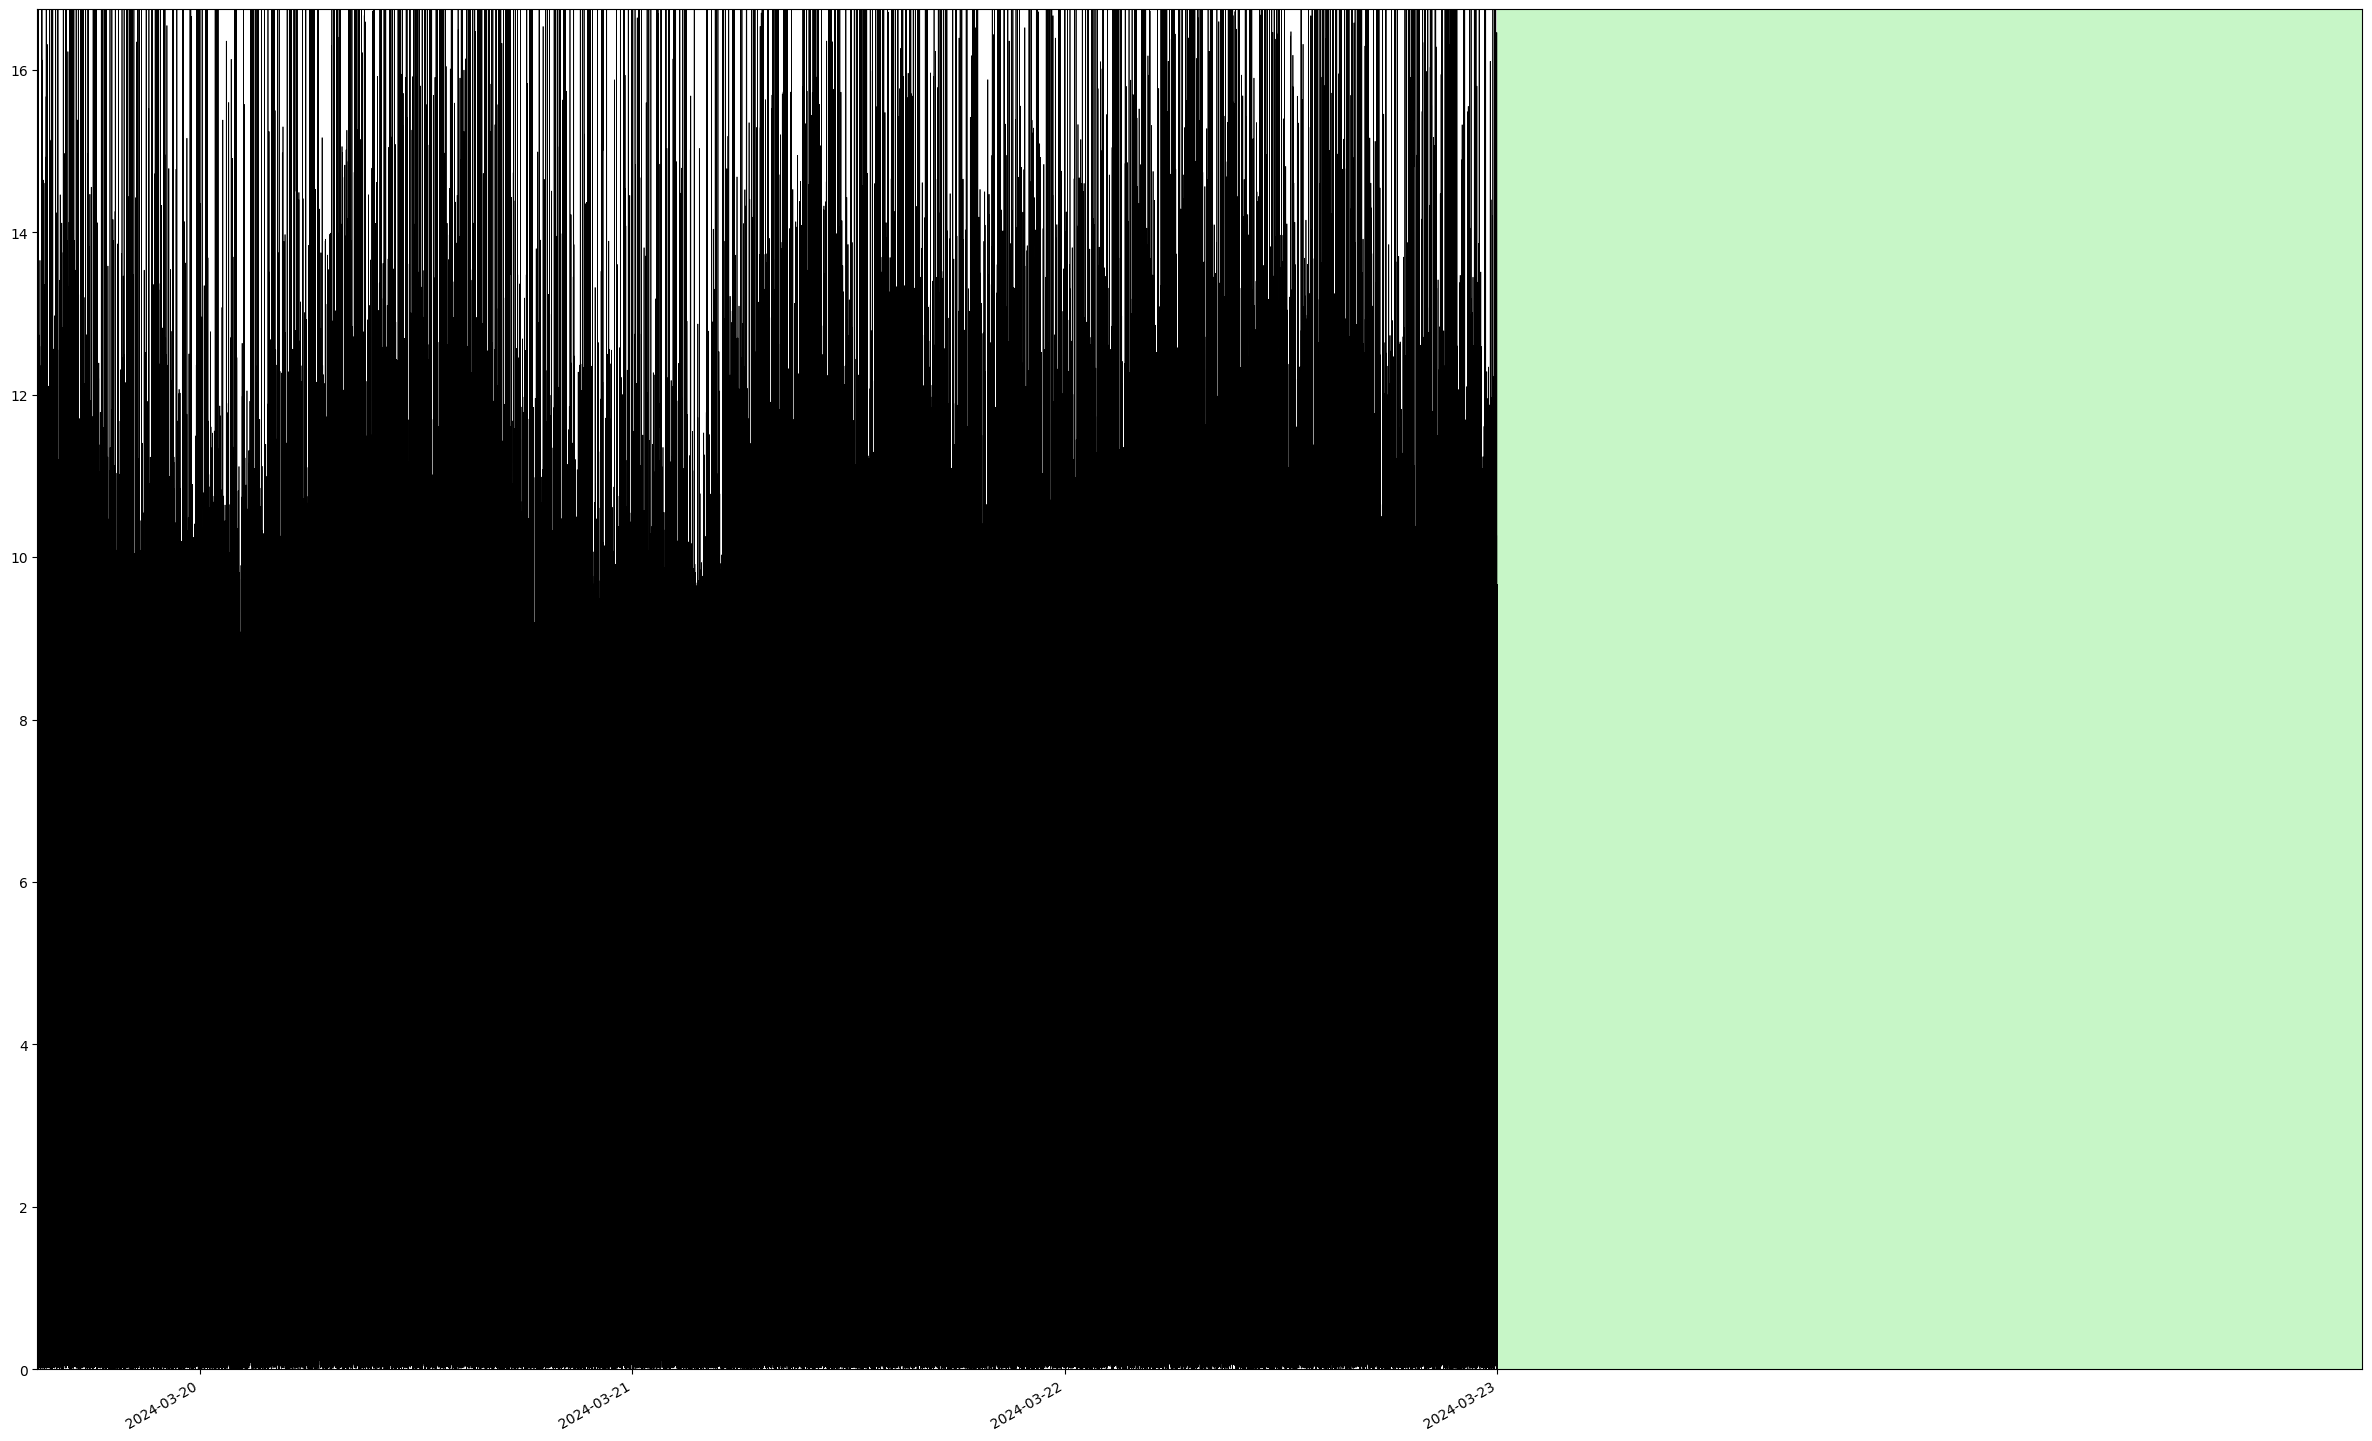

In [8]:
fig = plt.figure(figsize=(30,20))
tr = st2[0]
plt.plot(tr.times("matplotlib"), tr.data, c='k', lw=0.5)
dr = pd.date_range(tr.stats.starttime.date, tr.stats.endtime.date, freq="W-SAT")
for d in dr:
    plt.axvspan(d, d+datetime.timedelta(days=2), zorder=-1, alpha=0.5, ec="none", fc="lightgreen")

dr = pd.date_range(tr.stats.starttime.date, tr.stats.endtime.date, freq="D")
plt.xticks(list(dr), [d.strftime("%Y-%m-%d") for d in list(dr)])

plt.margins(0)

tr.data = tr.data[np.isfinite(tr.data)]
ylim_max = tr.data.std()
print(ylim_max)
plt.ylim(0,ylim_max)

fig.autofmt_xdate()
plt.savefig("groundmotion_continuous_with_weekends.pdf")

# ALL IN ONE
Once you defined your params, let's do it all in one for all stations. 

In [9]:
# Path to where you have copied the DATA/ folder (that contains the SDS, RESP etc folders)
DATA_PATH = '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/'
SDS = 'SDS'
network = 'XG'
year = '2024'

######
OUT_PATH = os.path.join(DATA_PATH, 'OUTPUT') 
if not os.path.exists(OUT_PATH):
    os.makedirs(OUT_PATH)
print(OUT_PATH)

stations = os.listdir(os.path.join(DATA_PATH, SDS, year, network))
stations
#sorted(glob.glob(os.path.join(DATA_PATH, SDS, year, network, station, '*Z.D', '*')))
print(len(stations))

/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/OUTPUT
20


In [10]:
# select to use common start- and endtime for all stations
common_time = True
common_starttime = "2024-03-19 00:00:00"
common_endtime = "2024-03-23 00:00:00"

## dictionary for muting start- and endtimes for specific stations
## you may want to add other stations !
trim_times= {'C29': ["2024-03-19 15:00:00","2024-03-23 00:00:00"]}

filtertype = 'highpass' # 'highpass', 'bandpass' 
freq_min, freq_max = (4,14) #for highpass it takes the freq_min, for bandpass both values

####
for station in stations:
    print(station)
    files = sorted(glob.glob(os.path.join(DATA_PATH, SDS, year, network, station, '*Z.D', '*')))
    traces = []

    for file in files:
        print(file)
        try:
            st = read(file)
        except:
            print(f"Error reading {file}")
            continue
        st.decimate(10, no_filter=False)
        
        # play with the filters, you might want to filter the broadband data
        if filtertype == 'highpass':
            st.filter('highpass', freq=freq_min, corners=4, zerophase=True)
        if filtertype == 'bandpass':
            st.filter('bandpass', freqmin=freq_min, freqmax=freq_max, corners=4, zerophase=True)
        
        traces.append(st[0])
        
        del(st)
    st = Stream(traces=traces)
    st.merge()
    
    if st[0].stats.station in trim_times: 
        st.trim(starttime=UTCDateTime(trim_times[st[0].stats.station][0]), endtime=UTCDateTime(trim_times[st[0].stats.station][1]))
    
    if common_time:
        st.trim(starttime=UTCDateTime(common_starttime), endtime=UTCDateTime(common_endtime), pad=True, fill_value=None)

    outfile = "%s/%s_1hlines.pdf"%(OUT_PATH, st[0].id)
    st.plot(type='dayplot', interval=60, right_vertical_labels=False,
            one_tick_per_line=True,
            color=['black'], linewidth=0.5, show_y_UTC_label=False, 
             dpi=100, size=(5000,10000), y_labels_size=10, tick_format="%Y-%m-%d %Hh",
            subplots_adjust_left=0.03, subplots_adjust_right=0.98, subplots_adjust_top=0.98, 
            subplots_adjust_bottom=0.02, outfile=outfile)
    del(st)

S35
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/S35/GLZ.D/XG.S35..GLZ.D.2024.079
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/S35/GLZ.D/XG.S35..GLZ.D.2024.080
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/S35/GLZ.D/XG.S35..GLZ.D.2024.081
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/S35/GLZ.D/XG.S35..GLZ.D.2024.082
UP1
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/UP1/GLZ.D/XG.UP1..GLZ.D.2024.079
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/XG/UP1/GLZ.D/XG.UP1..GLZ.D.2024.080
/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_Observatio

IndexError: list index out of range